# 24BAD088 Pradeep Manikandan D
# Intel Image Classification
This notebook is optimized for faster Google Colab execution.

**Dataset:** https://www.kaggle.com/datasets/puneet6060/intel-image-classification

**Model:** MobileNetV2 (lightweight pre-trained vision model) + Hugging Face ViT

Speed settings: 160x160 images, batch size 64, 2 epochs, frozen base model, prefetch.


In [1]:
!pip install -q kagglehub transformers

In [2]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


In [3]:
import kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir = os.path.join(path, "seg_test", "seg_test")

print("Dataset:", path)
print("Classes:", sorted(os.listdir(train_dir)))

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset: /kaggle/input/intel-image-classification
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [4]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 64
EPOCHS = 2
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training",
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="validation",
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="categorical", shuffle=False
)

class_names = train_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Classes:", class_names)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


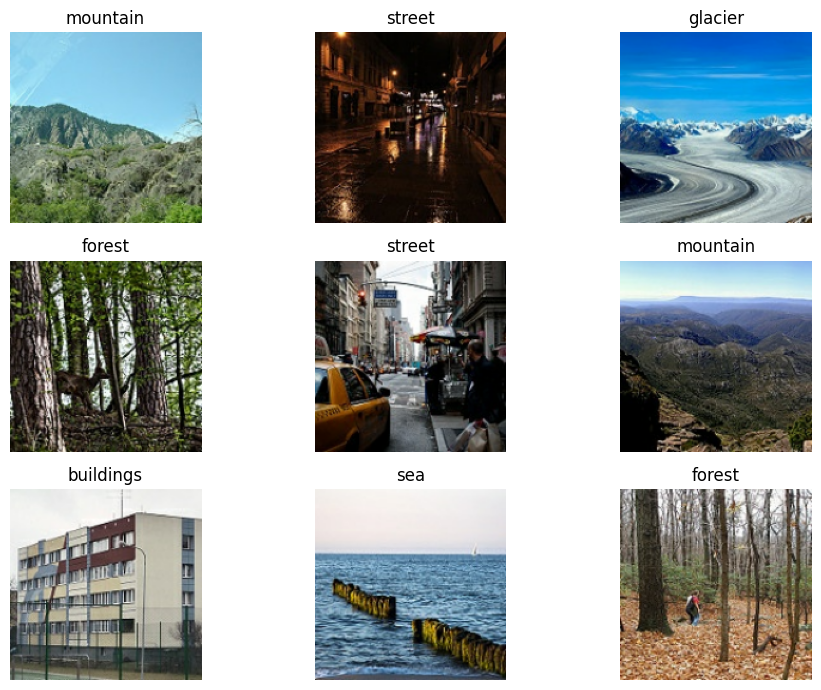

In [5]:
# Sample images
plt.figure(figsize=(10, 7))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")
plt.tight_layout()
plt.show()

## Part B – Transfer Learning

MobileNetV2 is used instead of ResNet50 because it is much lighter and faster in Google Colab while still demonstrating transfer learning with a pre-trained vision model.

In [6]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(160, 160, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(160, 160, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Frozen layers:", len(base_model.layers))
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Frozen layers: 154


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# Fast training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/2
176/176 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.8686 - loss: 0.3665 - val_accuracy: 0.9173 - val_loss: 0.2321
Epoch 2/2
176/176 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.9194 - loss: 0.2286 - val_accuracy: 0.9170 - val_loss: 0.2204


In [8]:
# Test performance
test_loss, test_accuracy = model.evaluate(test_ds)

print("\nRESULTS")
print("-" * 40)
print("Training Accuracy   :", round(history.history["accuracy"][-1], 4))
print("Validation Accuracy :", round(history.history["val_accuracy"][-1], 4))
print("Training Loss       :", round(history.history["loss"][-1], 4))
print("Validation Loss     :", round(history.history["val_loss"][-1], 4))
print("Test Accuracy       :", round(test_accuracy, 4))

47/47 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9163 - loss: 0.2288

RESULTS
----------------------------------------
Training Accuracy   : 0.9194
Validation Accuracy : 0.917
Training Loss       : 0.2286
Validation Loss     : 0.2204
Test Accuracy       : 0.9163


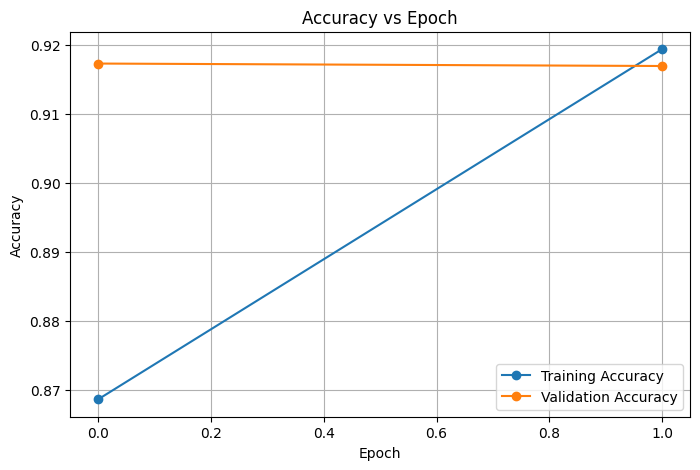

In [9]:
# Accuracy graph
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

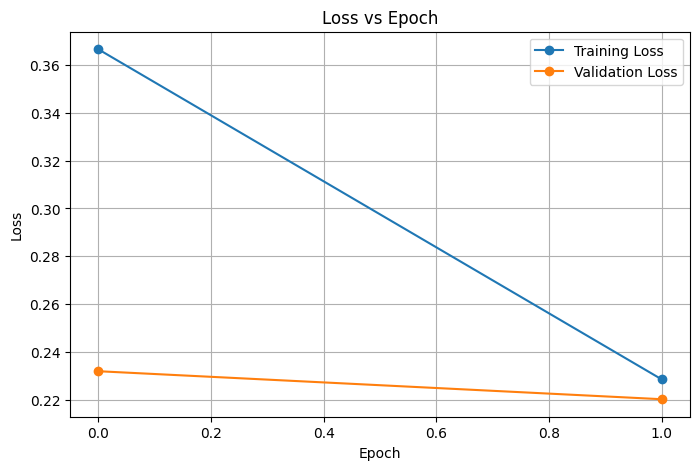

In [10]:
# Loss graph
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

## Part D – Hugging Face Vision Model

In [12]:
from transformers import pipeline

hf_model = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

print("Hugging Face Vision Transformer loaded successfully!")

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Hugging Face Vision Transformer loaded successfully!


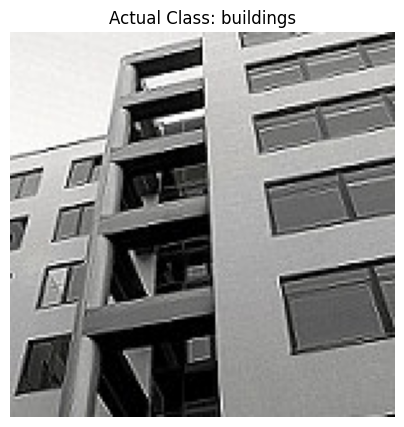

In [13]:
# Random test image
selected_class = random.choice(class_names)
folder = os.path.join(test_dir, selected_class)
filename = random.choice(os.listdir(folder))
image_path = os.path.join(folder, filename)

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title("Actual Class: " + selected_class)
plt.axis("off")
plt.show()

In [14]:
# Hugging Face prediction
hf_predictions = hf_model(image)

print("Hugging Face predictions:")
for p in hf_predictions[:3]:
    print(p["label"], "->", round(p["score"]*100, 2), "%")

Hugging Face predictions:
crane -> 41.6 %
traffic light, traffic signal, stoplight -> 5.65 %
flagpole, flagstaff -> 5.4 %


In [15]:
# MobileNetV2 prediction on same image
img = image.resize(IMG_SIZE)
arr = np.array(img, dtype=np.float32)[None, ...]
pred = model.predict(arr, verbose=0)

idx = np.argmax(pred)
mobile_class = class_names[idx]
mobile_conf = pred[0][idx] * 100

print("Actual Class            :", selected_class)
print("MobileNetV2 Prediction  :", mobile_class)
print("MobileNetV2 Confidence  :", round(mobile_conf, 2), "%")
print("Hugging Face Prediction :", hf_predictions[0]["label"])
print("Hugging Face Confidence :", round(hf_predictions[0]["score"]*100, 2), "%")

Actual Class            : buildings
MobileNetV2 Prediction  : buildings
MobileNetV2 Confidence  : 100.0 %
Hugging Face Prediction : crane
Hugging Face Confidence : 41.6 %
